# IMDB Dataset Analysis

**Author:** Jash Damani


In [2]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np                 
import yfinance as yf              
from datetime import datetime      
import matplotlib.cm as cm         
import matplotlib.ticker as mtick  
import warnings                    
from skimpy import skim            


warnings.filterwarnings('ignore')  

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (6.75, 6.75)


# Analysis of movies- IMDB dataset

We will look at a subset sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [4]:
# Load movies data

movies = pd.read_csv('../../data/movies.csv')


# Printing out information of the dataset

print(movies.info())


# Printing the first few observations of the dataset

movies.head()

skim(movies)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                2961 non-null   object 
 1   genre                2961 non-null   object 
 2   director             2961 non-null   object 
 3   year                 2961 non-null   int64  
 4   duration             2961 non-null   int64  
 5   gross                2961 non-null   int64  
 6   budget               2961 non-null   int64  
 7   cast_facebook_likes  2961 non-null   int64  
 8   votes                2961 non-null   int64  
 9   reviews              2961 non-null   int64  
 10  rating               2961 non-null   float64
dtypes: float64(1), int64(7), object(3)
memory usage: 254.6+ KB
None


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 2961   │ │ int64       │ 7     │                                                          │
│ │ Number of columns │ 11     │ │ string      │ 3     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column      ┃ NA ┃ NA % ┃ mean     ┃ sd       ┃ p0   ┃ p25      ┃ p50      ┃ p75      ┃ p100      ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ year        │  0 │    0 │     2003 │    9.946 │ 1920 │     1999 │     2004 │     2010 │      2016 │     ▃█ │  │
│ │ duration    │  0 │    0 │    109.6 │    22.17 │   37 │       95 │      106 │      119 │       330 │  ▁█▁   │  │
│ │ gross       │  0 │    0 │ 58090000 │ 72470000 │  703 │ 12280000 │ 34700000 │ 75590000 │ 760500000 │   █▁   │  │
│ │ budget      │  0 │    0 │ 40620000 │ 43680000 │  218 │ 11000000 │ 26000000 │ 55000000 │ 300000000 │  █▂▁   │  │
│ │ cast_facebo │  0 │    0 │    12390 │    20530 │    0 │     2241 │     4604 │    16930 │    656700 │   █    │  │
│ │ ok_likes    │    │      │          │          │      │          │          │          │           │        │  │
│ │ votes       │  0 │    0 │   109300 │   158100 │    5 │    19920 │    55750 │   133300 │   1690000 │   █▁   │  │
│ │ reviews     │  0 │    0 │    503.3 │    493.7 │    2 │      199 │      364 │      631 │      5312 │   █▁   │  │
│ │ rating      │  0 │    0 │    6.389 │    1.052 │  1.6 │      5.8 │      6.5 │      7.1 │       9.3 │   ▂█▆▁ │  │
│ └─────────────┴────┴──────┴──────────┴──────────┴──────┴──────────┴──────────┴──────────┴───────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃          ┃    ┃      ┃          ┃           ┃            ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column   ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min        ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ title    │  0 │    0 │ O        │ Borat:    │ 10         │ xXx:      │       15.3 │       2.8 │       8262 │  │
│ │          │    │      │          │ Cultural  │ Cloverfiel │ State of  │            │           │            │  │
│ │          │    │      │          │ Learnings │ d Lane     │ the Union │            │           │            │  │
│ │          │    │      │          │ of        │            │           │            │           │            │  │
│ │          │    │      │          │ America   │            │           │            │           │            │  │
│ │          │    │      │          │ for Make  │            │           │            │           │            │  │
│ │          │    │      │          │ Benefit   │       

Besides the obvious variables of title, genre, director, year, and duration, the rest of the variables are as follows:

- gross : The gross earnings in the US box office, not adjusted for inflation

- budget: The movie's budget

- cast_facebook_likes: the number of facebook likes cast memebrs received

- votes: the number of people who voted for (or rated) the movie in IMDB

- reviews: the number of reviews for that movie

- rating: IMDB average rating

## Import data, inspecting, and cleaning it to:

- Check if there are there any missing values (NAs)? Are all entries distinct or are there duplicate entries?
  
- Produce a table with the count of movies by genre, ranked in descending order
  
- Produce a table with the average gross earning and budget (gross and budget) by genre. Calculate a variable return_on_budget which shows how many dollars did a movie make at the box office for each dollar of its budget. Ranked genres by this return_on_budget in descending order
  
- Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director.
  
- Finally, ratings. Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.

In [6]:
# Data inspection and cleaning

# First, we calculate the total no. of missing values in our dataset's columns
miss_values =movies.isna().sum()

# Print the result
print(f'nummber of missing values in each column: \n{miss_values}')

nummber of missing values in each column: 
title                  0
genre                  0
director               0
year                   0
duration               0
gross                  0
budget                 0
cast_facebook_likes    0
votes                  0
reviews                0
rating                 0
dtype: int64


In [7]:
# Next, we compute the duplicates. First step is to check if there are records which are duplicated for all rows
duplicates_entire_row = movies[movies.duplicated()]
print(duplicates_entire_row)

Empty DataFrame
Columns: [title, genre, director, year, duration, gross, budget, cast_facebook_likes, votes, reviews, rating]
Index: []


In [8]:
# Second step is to check for duplicates at row level, premise is that title-director-year combination should be unique
count_duplicates = movies.duplicated(subset = ['title', 'director','year']).sum()
# Extract the duplicate rows
duplicates_row_level = movies[movies.duplicated(subset = ['title', 'director','year'], keep=False)]
# Print the duplicate rows
duplicates_row_level

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
34,Spider-Man 3,Action,Sam Raimi,2007,156,336530303,258000000,46055,383056,2294,6.2
35,Spider-Man 3,Action,Sam Raimi,2007,156,336530303,258000000,46055,383071,2294,6.2
37,Alice in Wonderland,Adventure,Tim Burton,2010,108,334185206,200000000,79957,306320,1187,6.5
38,Alice in Wonderland,Adventure,Tim Burton,2010,108,334185206,200000000,79957,306336,1187,6.5
94,Oz the Great and Powerful,Adventure,Sam Raimi,2013,130,234903076,215000000,73441,175409,1036,6.4
...,...,...,...,...,...,...,...,...,...,...,...
2278,The Astronaut's Wife,Drama,Rand Ravich,1999,109,10654581,34000000,52621,45500,367,5.3
2286,Sabotage,Action,David Ayer,2014,109,10499968,35000000,1458,47498,445,5.7
2287,Sabotage,Action,David Ayer,2014,109,10499968,35000000,1458,47502,445,5.7
2476,Victor Frankenstein,Drama,Paul McGuigan,2015,110,5773519,40000000,12876,28618,250,6.0


There are no NAs in this dataset. Not all entries are distinct and there are 54 duplicate entries. At first glance, movies gives no duplicates when we try checking for duplicates at a dataset level. However, when investigated further, to check if there were records with the same title, director and year (our argument is that there could be multiple movies with the same title, but might be launched in different years or could have been directed by different directors), we found that there were records with the same title, director, year ... but with different votes. With this observation, it is believed that there are indeed contextual duplicates in the dataset.

In [9]:
#Create new dataframe without duplicates for further analysis
movies_new = movies.drop_duplicates(subset = ['title', 'director','year'], keep='first')
print(movies_new.shape)

# Use shape function to see how many rows are removed due to duplication
print(movies.shape)

# Create a new dataframe using the Spider-Man 3 movie as an example to understand why there are duplicates.
spiderman3 = movies[movies['title'] == 'Spider-Man 3']
# Inspect the Spiderman 3 movies
print(spiderman3)

# Print the number of duplicates found
print(f'number of duplicates = {count_duplicates}')

(2907, 11)
(2961, 11)
           title   genre   director  year  duration      gross     budget  \
34  Spider-Man 3  Action  Sam Raimi  2007       156  336530303  258000000   
35  Spider-Man 3  Action  Sam Raimi  2007       156  336530303  258000000   

    cast_facebook_likes   votes  reviews  rating  
34                46055  383056     2294     6.2  
35                46055  383071     2294     6.2  
number of duplicates = 54


In [ ]:
# We want to the check the no. of observations for each genre. We used the clean dataset for the analysis
movies_new['genre'].value_counts(ascending=False)

genre
Comedy         844
Action         719
Drama          484
Adventure      281
Crime          198
Biography      135
Horror         128
Animation       35
Fantasy         26
Documentary     25
Mystery         15
Sci-Fi           7
Family           3
Musical          2
Romance          2
Western          2
Thriller         1
Name: count, dtype: int64

In [11]:
# Data Manipulation
# Calculate return on budget by genre and show in descending order
avg_gross_earnings = (movies_new.groupby('genre')
    .agg(avg_gross=('gross', 'mean'), avg_budget=('budget', 'mean'))
)

print(avg_gross_earnings)

# We defined return on budget for a genre = total gross (of all movies in a genre) / total budget (of all movies in a genre)
genre_rank = (
    movies_new.groupby('genre')
    .apply(lambda df: df['gross'].sum() / df['budget'].sum())
    .reset_index()
)

# Sort by return on budget in descending order
genre_rank.columns = ['genre', 'return_on_budget']
genre_rank = genre_rank.sort_values(by='return_on_budget', ascending=False)
# genre_rank['return_on_budget'] = genre_rank['gross'] / genre_rank['budget']
genre_rank

                avg_gross    avg_budget
genre                                  
Action       8.627034e+07  7.077456e+07
Adventure    9.435024e+07  6.469231e+07
Animation    9.843379e+07  6.170143e+07
Biography    4.520181e+07  2.854370e+07
Comedy       4.248781e+07  2.445851e+07
Crime        3.760153e+07  2.652740e+07
Documentary  1.735397e+07  5.887852e+06
Drama        3.675496e+07  2.583261e+07
Family       1.491605e+08  1.483333e+07
Fantasy      4.190267e+07  1.848462e+07
Horror       3.778231e+07  1.380438e+07
Musical      9.208400e+07  3.189500e+06
Mystery      6.911714e+07  4.150000e+07
Romance      3.126485e+07  2.510750e+07
Sci-Fi       2.978837e+07  2.760714e+07
Thriller     2.468000e+03  3.000000e+05
Western      2.082188e+07  3.465000e+06


,genre,return_on_budget
11,Musical,28.870983
8,Family,10.055763
16,Western,6.009202
6,Documentary,2.947420
10,Horror,2.736980
9,Fantasy,2.266895
4,Comedy,1.737138
12,Mystery,1.665473
2,Animation,1.595324
3,Biography,1.583600


In [12]:
# Top 15 directors by gross revenue
director_gross_stats = (movies_new.groupby('director')['gross']
    .agg(['sum', 'mean', 'median', 'std', 'count'])
    .rename(columns={'sum': 'total_gross', 'mean': 'mean_gross', 'median': 'median_gross', 'std': 'std_gross', 'count': 'num_movies'})
    .sort_values('total_gross', ascending=False)
    .head(15)
)

director_gross_stats = director_gross_stats.round({'total_gross': 0, 'mean_gross': 0, 'median_gross': 0, 'std_gross': 0})
director_gross_stats.reset_index(inplace=True)
director_gross_stats.style.format({'total_gross': '{:,.0f}', 'mean_gross': '{:,.0f}', 'median_gross': '{:,.0f}', 'std_gross': '{:,.0f}'})

director_gross_stats

,director,total_gross,mean_gross,median_gross,std_gross,num_movies
0,Steven Spielberg,4014061704,174524422.0,164435221.0,101421051.0,23
1,Michael Bay,2195443511,182953626.0,168468240.0,125789167.0,12
2,James Cameron,1909725910,318287652.0,175562880.0,309171337.0,6
3,Christopher Nolan,1813227576,226653447.0,196667606.0,187224133.0,8
4,George Lucas,1741418480,348283696.0,380262555.0,146193880.0,5
5,Robert Zemeckis,1619309108,124562239.0,100853835.0,91300279.0,13
6,Tim Burton,1557078534,111219895.0,69791834.0,99304293.0,14
7,Sam Raimi,1443167519,180395940.0,138480208.0,174705230.0,8
8,Clint Eastwood,1378321100,72543216.0,46700000.0,75487408.0,19
9,Francis Lawrence,1358501971,271700394.0,281666058.0,135437020.0,5


In [13]:
# Ratings distribution by genre
ratings_by_genre = (movies.groupby('genre')['rating']
    .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
    .rename(columns={'mean': 'mean_rating', 'median': 'median_rating', 'std': 'std_rating', 'min': 'min_rating', 'max': 'max_rating', 'count': 'num_movies'})
    .sort_values('mean_rating', ascending=False)
)

ratings_by_genre = ratings_by_genre.round({'mean_rating': 2, 'median_rating': 2, 'std_rating': 2, 'min_rating': 2, 'max_rating': 2})
ratings_by_genre.reset_index(inplace=True)
ratings_by_genre

,genre,mean_rating,median_rating,std_rating,min_rating,max_rating,num_movies
0,Biography,7.11,7.20,0.76,4.5,8.9,135
1,Crime,6.92,6.90,0.85,4.8,9.3,202
2,Mystery,6.86,6.90,0.88,4.6,8.5,16
3,Musical,6.75,6.75,0.64,6.3,7.2,2
4,Drama,6.73,6.80,0.92,2.1,8.8,498
5,Documentary,6.66,7.40,1.77,1.6,8.5,25
6,Sci-Fi,6.66,6.40,1.09,5.0,8.2,7
7,Animation,6.65,6.90,0.97,4.5,8.0,35
8,Romance,6.65,6.65,0.64,6.2,7.1,2
9,Adventure,6.51,6.60,1.09,2.3,8.6,288


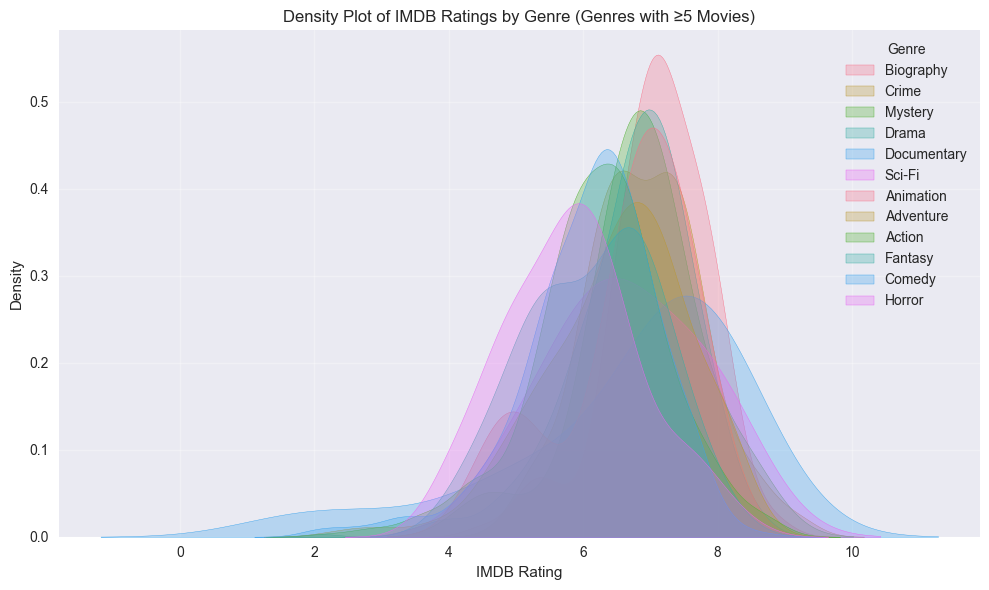

In [14]:
# Density plot of ratings by genre (for genres with at least 5 movies)
genres_with_enough_movies = ratings_by_genre[ratings_by_genre['num_movies'] >= 5]['genre']
plt.figure(figsize=(10, 6))
for genre in genres_with_enough_movies:
    sns.kdeplot(movies[movies['genre'] == genre]['rating'].dropna(), label=genre, fill=True, alpha=0.3)
plt.xlabel('IMDB Rating')
plt.ylabel('Density')
plt.title('Density Plot of IMDB Ratings by Genre (Genres with ≥5 Movies)')
plt.legend(title='Genre')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

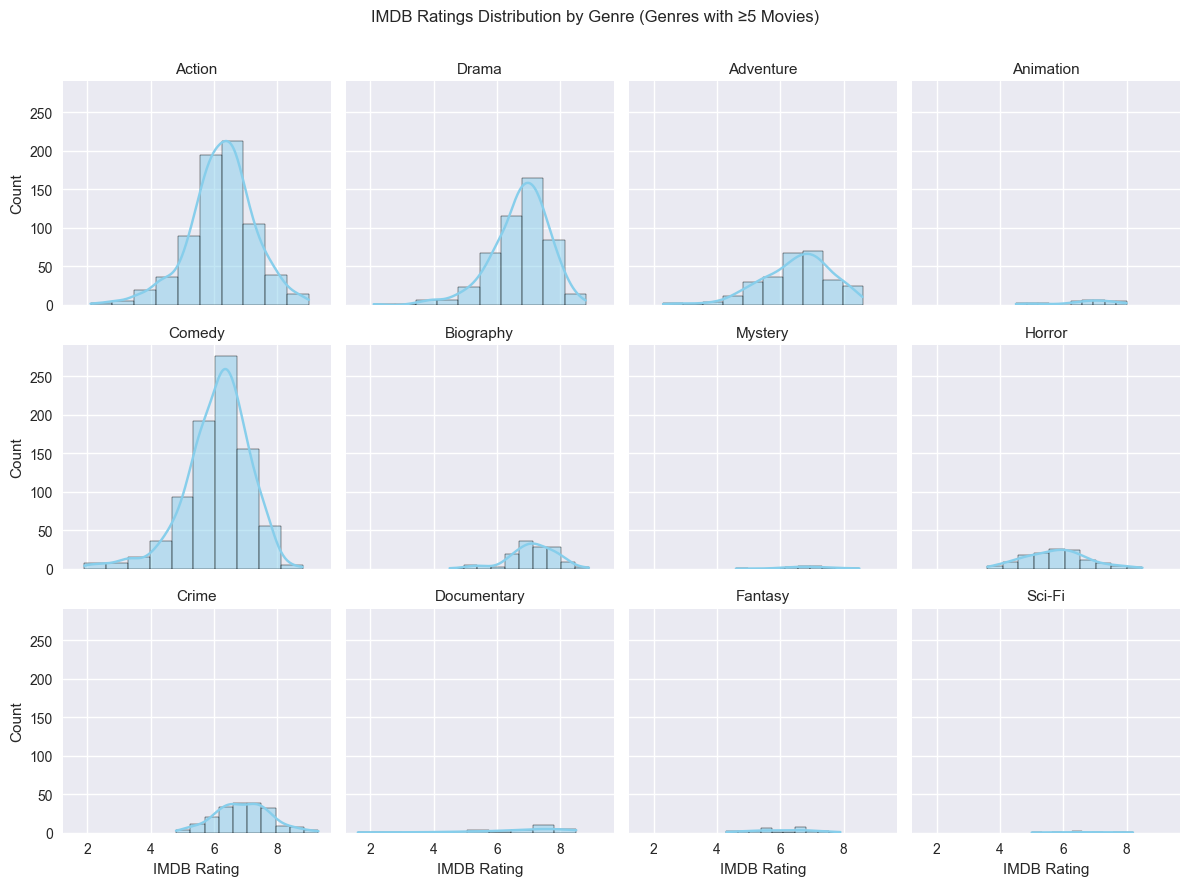

In [15]:
# Histogram of ratings by genre
# Filter for genres with at least 5 movies
genre_counts = movies_new['genre'].value_counts()
genres_with_5plus = genre_counts[genre_counts >= 5].index.tolist()
filtered_movies = movies_new[movies_new['genre'].isin(genres_with_5plus)]

# Plot all histograms together using seaborn's FacetGrid
g = sns.FacetGrid(filtered_movies, col="genre", col_wrap=4, sharex=True, sharey=True, height=3)
g.map_dataframe(sns.histplot, x="rating", bins=10, kde=True, color="skyblue")
g.set_axis_labels("IMDB Rating", "Count")
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('IMDB Ratings Distribution by Genre (Genres with ≥5 Movies)')
plt.show()

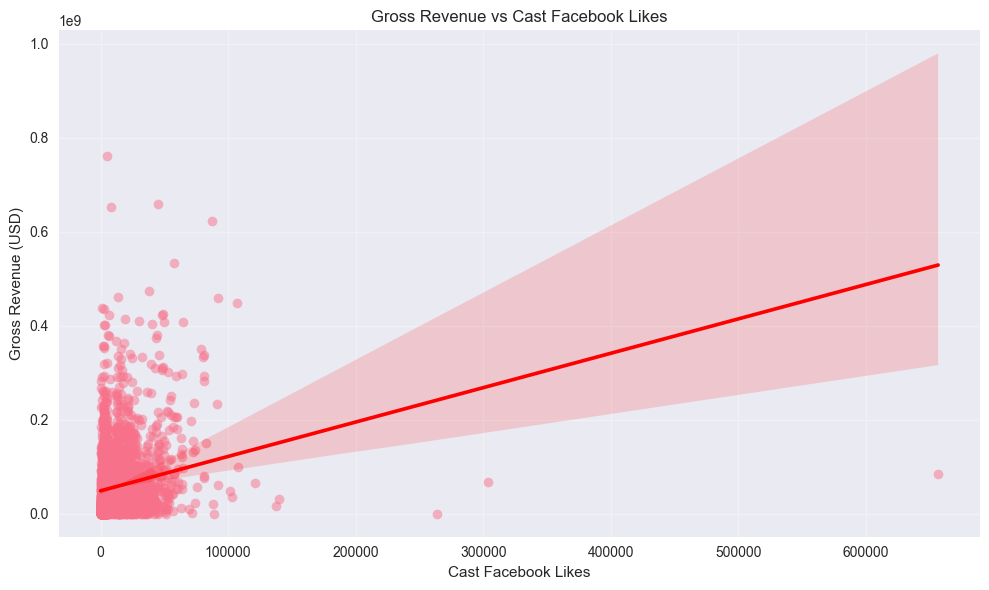

Correlation between gross and cast facebook likes: 0.208


In [16]:
	
# Scatter plot: Gross vs Cast Facebook Likes

plt.figure(figsize=(10, 6))

# Scatter plot with regression line
sns.regplot(data=movies_new, x='cast_facebook_likes', y='gross', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.xlabel('Cast Facebook Likes')
plt.ylabel('Gross Revenue (USD)')
plt.title('Gross Revenue vs Cast Facebook Likes')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

# --- Correlation Calculation ---
# Calculate the Pearson correlation coefficient.
correlation = movies_new['gross'].corr(movies_new['cast_facebook_likes'])

# Print the result formatted to three decimal places.
print(f"Correlation between gross and cast facebook likes: {correlation:.3f}")

Data contain extreme outliers that heavily affect regression line and correlation is low. Therefore, facebook likes is not a very good predictor of how much money a movie will make.

Correlation between gross and budget: 0.639


<function matplotlib.pyplot.show(close=None, block=None)>

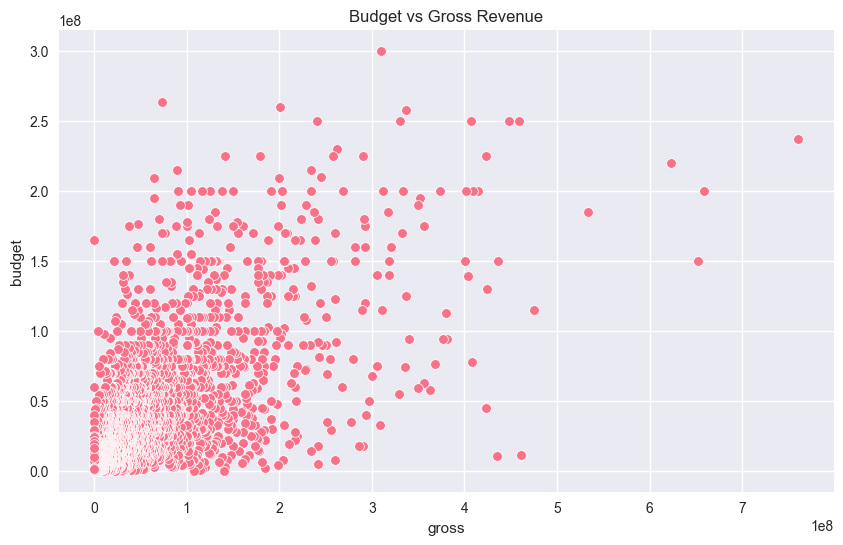

In [17]:
# Scatter plot: Gross vs Budget
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movies_new, x='gross', y='budget')

# Calculate the Pearson correlation coefficient.
correlation = movies_new['gross'].corr(movies_new['budget'])
print(f"Correlation between gross and budget: {correlation:.3f}")

plt.title('Budget vs Gross Revenue')
plt.show

Budget seems to be much better indicator of gross revenues for a movies compared to facebook likes with a pearson correlation factor much closer to 1.

Correlation between gross and rating: 0.274


<function matplotlib.pyplot.show(close=None, block=None)>

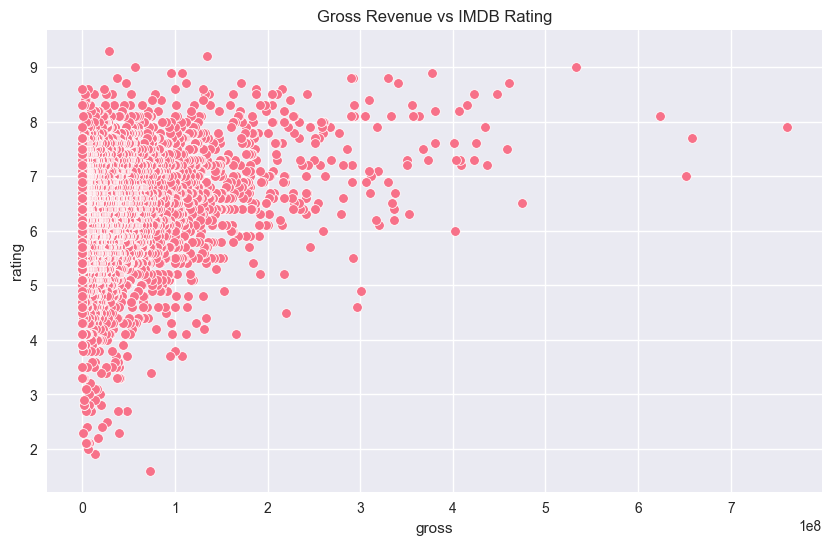

In [18]:
# Scatter plot: Gross vs Rating by Genre- for genres that have at least 5 movies
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movies_new, x='gross', y='rating')

# Calculate the Pearson correlation coefficient.
correlation = movies_new['gross'].corr(movies_new['rating'])
print(f"Correlation between gross and rating: {correlation:.3f}")
plt.title('Gross Revenue vs IMDB Rating')
plt.show

Rating is not a good indicator for a movie's gross revenue. Correlation factor similair to that of Facebook likes.